# Phase 0: Blind Community Detection on Polymarket

**Test:** Pick two unrelated high-volume events (e.g. fed rates + sports), pool all their
sub-markets into one dataset, run BlindCD with K=2, and check whether the clustering
correctly recovers which event each market belongs to.

If it can't even separate two obviously different domains from co-movement data alone,
nothing else downstream will work.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import asyncio
import json
from datetime import datetime, timezone, timedelta

import numpy as np
import polars as pl

from src.api import get_events, get_markets_for_event, get_markets_by_event_id, fetch_all_price_histories
from src.pipeline import build_panel, compute_log_odds_returns, run_blindcd
from src.plots import plot_eigenvalue_spectrum, plot_covariance_heatmap, plot_embedding, print_clusters

%matplotlib inline

## 1. Explore available events

Pull events from the Gamma API and find two high-volume events from different domains,
each with enough active sub-markets.

In [2]:
# Fetch a broad set of events (multiple pages to get variety)
all_events = []
for offset in range(0, 500, 100):
    batch = get_events(limit=100, offset=offset)
    if not batch:
        break
    all_events.extend(batch)
    print(f"  Fetched {len(batch)} events at offset {offset} (total: {len(all_events)})")

print(f"\nTotal events fetched: {len(all_events)}")

  Fetched 100 events at offset 0 (total: 100)
  Fetched 100 events at offset 100 (total: 200)
  Fetched 100 events at offset 200 (total: 300)
  Fetched 100 events at offset 300 (total: 400)
  Fetched 100 events at offset 400 (total: 500)

Total events fetched: 500


In [3]:
# Score events: prefer 8-20 active sub-markets, high volume
def score_event(event):
    markets = event.get("markets", [])
    if not isinstance(markets, list):
        return -1
    n = len(markets)
    total_vol = float(event.get("volume", 0) or 0)
    if n < 6:
        return -1
    active_markets = sum(1 for m in markets if float(m.get("volume", 0) or 0) > 1000)
    if active_markets < 5:
        return -1
    size_score = 1.0 if 8 <= n <= 25 else 0.8 if 6 <= n <= 30 else 0.3
    active_ratio = active_markets / n
    vol_score = min(total_vol / 1_000_000, 10)
    return size_score * active_ratio * vol_score

scored = [(score_event(e), e) for e in all_events]
scored = [(s, e) for s, e in scored if s > 0]
scored.sort(key=lambda x: -x[0])

print(f"Events with 5+ active markets: {len(scored)}\n")
print("Top 20 candidates:")
print("-" * 110)
for score, e in scored[:20]:
    markets = e.get("markets", [])
    n = len(markets) if isinstance(markets, list) else 0
    active = sum(1 for m in markets if float(m.get("volume", 0) or 0) > 1000)
    vol = float(e.get("volume", 0) or 0)
    print(f"  score={score:>6.2f}  mkts={n:2d}  active={active:2d}  vol=${vol:>12,.0f}  {e.get('slug', '?')[:40]}  {e.get('title', '?')[:40]}")

Events with 5+ active markets: 168

Top 20 candidates:
--------------------------------------------------------------------------------------------------------------
  score= 10.00  mkts= 9  active= 9  vol=$  21,387,230  what-will-happen-before-gta-vi  What will happen before GTA VI?
  score= 10.00  mkts= 8  active= 8  vol=$  18,740,085  megaeth-market-cap-fdv-one-day-after-lau  MegaETH market cap (FDV) one day after l
  score= 10.00  mkts=13  active=13  vol=$  20,873,377  how-many-fed-rate-cuts-in-2026  How many Fed rate cuts in 2026?
  score= 10.00  mkts=17  active=17  vol=$  17,520,859  which-companies-will-be-acquired-before-  Which companies will be acquired before 
  score=  8.00  mkts= 7  active= 7  vol=$  15,660,093  starmer-out-in-2025  Starmer out by...?
  score=  8.00  mkts= 7  active= 7  vol=$  26,712,565  will-trump-visit-china-by  Will Trump visit China by...?
  score=  8.00  mkts= 6  active= 6  vol=$  28,676,871  will-the-us-confirm-that-aliens-exist-be  Will the US conf

In [4]:
# Dynamically pick the top 2 highest-scored events from different domains.
# We just need 2+ markets per event to survive — take whatever's most liquid.

def slug_words(slug):
    return set(slug.replace("-", " ").split())

# Build candidate pairs: for each event, pair it with the next event sharing no slug words
candidate_pairs = []
for i, (sa, ea) in enumerate(scored):
    words_a = slug_words(ea.get("slug", ""))
    for j, (sb, eb) in enumerate(scored):
        if j <= i:
            continue
        words_b = slug_words(eb.get("slug", ""))
        if not words_a & words_b:
            candidate_pairs.append((ea, eb))
            break  # best partner for ea
    if len(candidate_pairs) >= 10:
        break

print(f"Candidate event pairs: {len(candidate_pairs)}")
for ea, eb in candidate_pairs[:10]:
    na = len(ea.get("markets", []))
    nb = len(eb.get("markets", []))
    print(f"  [{na} mkts] {ea.get('slug','?')[:35]:35s}  x  [{nb} mkts] {eb.get('slug','?')[:35]}")

Candidate event pairs: 10
  [9 mkts] what-will-happen-before-gta-vi       x  [8 mkts] megaeth-market-cap-fdv-one-day-afte
  [8 mkts] megaeth-market-cap-fdv-one-day-afte  x  [13 mkts] how-many-fed-rate-cuts-in-2026
  [13 mkts] how-many-fed-rate-cuts-in-2026       x  [17 mkts] which-companies-will-be-acquired-be
  [17 mkts] which-companies-will-be-acquired-be  x  [7 mkts] starmer-out-in-2025
  [7 mkts] starmer-out-in-2025                  x  [7 mkts] will-trump-visit-china-by
  [7 mkts] will-trump-visit-china-by            x  [16 mkts] nba-eastern-conference-champion-442
  [6 mkts] will-the-us-confirm-that-aliens-exi  x  [16 mkts] nba-eastern-conference-champion-442
  [16 mkts] nba-eastern-conference-champion-442  x  [24 mkts] french-ligue-1-winner
  [16 mkts] nba-western-conference-champion-933  x  [24 mkts] french-ligue-1-winner
  [24 mkts] french-ligue-1-winner                x  [16 mkts] how-many-different-countries-will-i


## 2. Pull price history and build panel

Try candidate event pairs until we find one where both events have 2+ markets surviving
the panel construction. This handles the reality that many Polymarket markets have sparse
or no CLOB price data.

In [5]:
# Time window
FIDELITY = 60  # minutes
LOOKBACK_DAYS = 14

end_dt = datetime.now(timezone.utc)
start_dt = end_dt - timedelta(days=LOOKBACK_DAYS)
start_ts = int(start_dt.timestamp())
end_ts = int(end_dt.timestamp())

print(f"Time window: {start_dt.date()} to {end_dt.date()} ({LOOKBACK_DAYS} days)")
print(f"Fidelity: {FIDELITY} min bars\n")

# Try candidate pairs until one yields 2+ non-flat markets per event
event_a = event_b = None
token_meta = {}
ground_truth = {}
signal_df = None

for pair_idx, (ea, eb) in enumerate(candidate_pairs):
    print(f"{'='*70}")
    print(f"Pair {pair_idx+1}: {ea['title'][:35]} x {eb['title'][:35]}")
    print(f"{'='*70}")

    # Extract Yes-side token IDs
    _token_ids = []
    _token_meta = {}
    _ground_truth = {}

    for event_label, ev in [("A", ea), ("B", eb)]:
        for m in ev.get("markets", []):
            clob = m.get("clobTokenIds")
            if isinstance(clob, str):
                clob = json.loads(clob)
            if clob and len(clob) >= 1:
                yes_id = clob[0]
                _token_ids.append(yes_id)
                _ground_truth[yes_id] = event_label
                _token_meta[yes_id] = {
                    "question": m.get("question", m.get("title", "?")),
                    "token_id": yes_id,
                    "volume": float(m.get("volume", 0) or 0),
                    "event": event_label,
                    "event_title": ev["title"],
                }

    print(f"  Tokens: {len(_token_ids)} (A={sum(1 for v in _ground_truth.values() if v=='A')}, B={sum(1 for v in _ground_truth.values() if v=='B')})")

    # Fetch price histories
    price_data = await fetch_all_price_histories(
        _token_ids, start_ts, end_ts, fidelity=FIDELITY, max_concurrent=3
    )

    # Assemble long-format DataFrame
    rows = []
    for tid, hist in price_data.items():
        points = hist.get("history", hist) if isinstance(hist, dict) else hist
        if not points:
            continue
        for pt in points:
            rows.append({
                "token_id": tid,
                "timestamp": datetime.fromtimestamp(int(pt["t"]), tz=timezone.utc),
                "price": float(pt["p"]),
            })

    if not rows:
        print("  → No price data, skipping.\n")
        continue

    prices_long = pl.DataFrame(rows)
    n_tokens_with_data = prices_long['token_id'].n_unique()
    print(f"  Price rows: {prices_long.shape[0]}, tokens with data: {n_tokens_with_data}")

    # Build panel
    _panel, _dropped = build_panel(prices_long, fidelity_minutes=FIDELITY, max_missing_frac=0.80)
    tcols = [c for c in _panel.columns if c != "timestamp"]

    # Drop completely flat markets (no price variation)
    _keep = ["timestamp"]
    for c in tcols:
        if _panel[c].std() is not None and _panel[c].std() > 1e-10:
            _keep.append(c)

    _signal = _panel.select(_keep).drop_nulls()
    sig_cols = [c for c in _signal.columns if c != "timestamp"]
    sa = sum(1 for c in sig_cols if _ground_truth.get(c) == "A")
    sb = sum(1 for c in sig_cols if _ground_truth.get(c) == "B")
    print(f"  After cleanup: {len(sig_cols)} markets (A={sa}, B={sb}), {_signal.height} bars")

    if sa >= 2 and sb >= 2:
        event_a, event_b = ea, eb
        token_meta = _token_meta
        ground_truth = _ground_truth
        signal_df = _signal
        print(f"  → SUCCESS!\n")
        break
    else:
        print(f"  → Not enough markets, trying next.\n")

assert signal_df is not None, "No candidate pair yielded 2+ non-flat markets per event"

sig_cols = [c for c in signal_df.columns if c != "timestamp"]
surviving_a = sum(1 for c in sig_cols if ground_truth.get(c) == "A")
surviving_b = sum(1 for c in sig_cols if ground_truth.get(c) == "B")

print(f"\nSelected events:")
print(f"  Event A: {event_a['title']}")
print(f"  Event B: {event_b['title']}")
print(f"  Signal: {signal_df.shape} ({surviving_a} A + {surviving_b} B markets, {signal_df.height} bars)")
print(f"\nPer-market price stats:")
for c in sig_cols:
    col = signal_df[c]
    label = token_meta.get(c, {}).get('question', c[:20])[:50]
    gt = token_meta.get(c, {}).get('event', '?')
    print(f"  [{gt}] mean={col.mean():.4f} std={col.std():.4f}  {label}")

Time window: 2026-04-11 to 2026-04-25 (14 days)
Fidelity: 60 min bars

Pair 1: What will happen before GTA VI? x MegaETH market cap (FDV) one day af
  Tokens: 17 (A=9, B=8)


  Price rows: 3472, tokens with data: 17
  After cleanup: 3 markets (A=1, B=2), 100 bars
  → Not enough markets, trying next.

Pair 2: MegaETH market cap (FDV) one day af x How many Fed rate cuts in 2026?
  Tokens: 21 (A=8, B=13)


  Price rows: 4489, tokens with data: 21
  After cleanup: 0 markets (A=0, B=0), 96 bars
  → Not enough markets, trying next.

Pair 3: How many Fed rate cuts in 2026? x Which companies will be acquired be
  Tokens: 30 (A=13, B=17)


  Price rows: 6097, tokens with data: 28
  After cleanup: 2 markets (A=2, B=0), 97 bars
  → Not enough markets, trying next.

Pair 4: Which companies will be acquired be x Starmer out by...?
  Tokens: 24 (A=17, B=7)


  Price rows: 3964, tokens with data: 19
  After cleanup: 1 markets (A=0, B=1), 97 bars
  → Not enough markets, trying next.

Pair 5: Starmer out by...? x Will Trump visit China by...?
  Tokens: 14 (A=7, B=7)


  Price rows: 1721, tokens with data: 9
  After cleanup: 7 markets (A=3, B=4), 183 bars
  → SUCCESS!


Selected events:
  Event A: Starmer out by...?
  Event B: Will Trump visit China by...?
  Signal: (183, 8) (3 A + 4 B markets, 183 bars)

Per-market price stats:
  [A] mean=0.5993 std=0.0131  Starmer out by December 31, 2026?
  [A] mean=0.0554 std=0.0081  Starmer out by April 30, 2026?
  [A] mean=0.2187 std=0.0048  Starmer out by May 15, 2026?
  [B] mean=0.0081 std=0.0020  Will Trump visit China by April 30?
  [B] mean=0.8697 std=0.0277  Will Trump visit China by June 30?
  [B] mean=0.8505 std=0.0515  Will Trump visit China by May 31?
  [B] mean=0.8039 std=0.0032  Will Trump visit China by May 15?


## 3. Build the panel and run BlindCD on price levels

Use **centered price levels** as the signal for covariance analysis, rather than log-odds
returns. Hourly returns on Polymarket are too sparse (most markets trade only a few times
per day), producing covariance matrices dominated by noise. Price levels avoid this:
markets within the same event share correlated trajectories, while cross-event markets don't.

## 4. Run BlindCD with K=2

The key test: can the algorithm recover the two-event structure purely from price
co-movements? We run spectral clustering on the covariance of centered price levels.

In [6]:
K = 2

# Use correlation matrix (not raw covariance) — normalizes out scale differences
# so clustering captures co-movement patterns, not absolute price levels.
result = run_blindcd(signal_df, K=K, use_correlation=True)

print(f"Eigenvalue spectrum (top 10):")
for i, ev in enumerate(result["eigenvalues"][:10]):
    print(f"  λ_{i+1} = {ev:.6f}")

# Build ground-truth labels for surviving markets
gt_labels = [ground_truth.get(tid, "?") for tid in result["token_ids"]]

print(f"\nCluster assignments (with ground truth):")
print(f"{'Cluster':>8}  {'GT':>3}  {'Market'}")
print("-" * 80)
for tid, cl in zip(result["token_ids"], result["labels"]):
    gt = ground_truth.get(tid, "?")
    q = token_meta.get(tid, {}).get("question", tid[:20])
    print(f"  {cl:>5}     {gt}   {q[:65]}")

Eigenvalue spectrum (top 10):
  λ_1 = 5.149341
  λ_2 = 1.519300
  λ_3 = 0.141352
  λ_4 = 0.104852
  λ_5 = 0.059379
  λ_6 = 0.025776
  λ_7 = 0.000000

Cluster assignments (with ground truth):
 Cluster   GT  Market
--------------------------------------------------------------------------------
      0     A   Starmer out by December 31, 2026?
      0     A   Starmer out by April 30, 2026?
      0     A   Starmer out by May 15, 2026?
      0     B   Will Trump visit China by April 30?
      0     B   Will Trump visit China by June 30?
      1     B   Will Trump visit China by May 31?
      1     B   Will Trump visit China by May 15?


## 5. Evaluate clustering accuracy

Since K-means labels are arbitrary (cluster 0 could map to event A or B), we check both
label permutations and report the best accuracy.

In [7]:
# Compute accuracy (best over label permutations)
gt_binary = np.array([0 if ground_truth.get(tid) == "A" else 1 for tid in result["token_ids"]])
pred = result["labels"]

acc_direct = np.mean(pred == gt_binary)
acc_flipped = np.mean(pred == (1 - gt_binary))
accuracy = max(acc_direct, acc_flipped)
best_mapping = ("0→A, 1→B" if acc_direct >= acc_flipped else "0→B, 1→A")

n_total = len(pred)
n_correct = int(accuracy * n_total)
n_wrong = n_total - n_correct

print(f"{'='*60}")
print(f"  CLUSTERING ACCURACY: {accuracy:.1%} ({n_correct}/{n_total})")
print(f"  Best label mapping: {best_mapping}")
print(f"  Misclassified: {n_wrong}")
print(f"{'='*60}")

# Show confusion matrix
if acc_direct >= acc_flipped:
    mapping = {0: "A", 1: "B"}
else:
    mapping = {0: "B", 1: "A"}

print(f"\nConfusion breakdown:")
for tid, cl in zip(result["token_ids"], result["labels"]):
    gt = ground_truth.get(tid, "?")
    predicted_event = mapping[cl]
    match = "✓" if predicted_event == gt else "✗"
    q = token_meta.get(tid, {}).get("question", tid[:20])
    print(f"  {match} GT={gt} pred={predicted_event}  {q[:55]}")

  CLUSTERING ACCURACY: 71.4% (5/7)
  Best label mapping: 0→A, 1→B
  Misclassified: 2

Confusion breakdown:
  ✓ GT=A pred=A  Starmer out by December 31, 2026?
  ✓ GT=A pred=A  Starmer out by April 30, 2026?
  ✓ GT=A pred=A  Starmer out by May 15, 2026?
  ✗ GT=B pred=A  Will Trump visit China by April 30?
  ✗ GT=B pred=A  Will Trump visit China by June 30?
  ✓ GT=B pred=B  Will Trump visit China by May 31?
  ✓ GT=B pred=B  Will Trump visit China by May 15?


In [8]:
## 6. Visualize

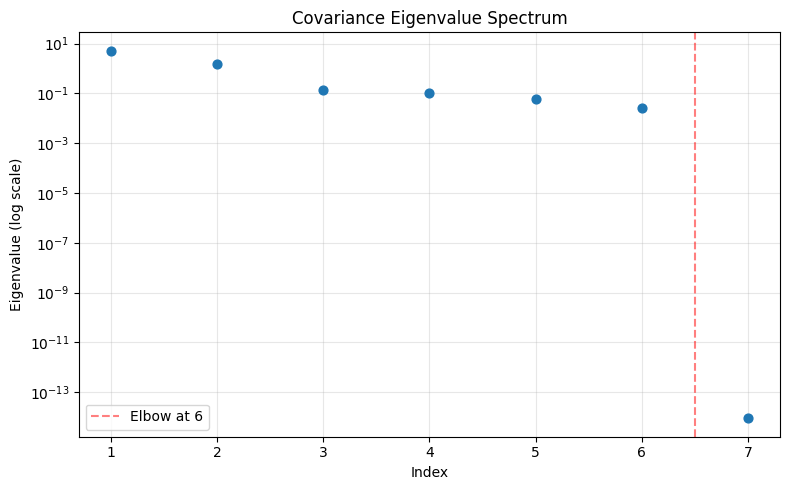

In [9]:
# Short labels: "[A] question..." or "[B] question..."
market_labels = [
    f"[{token_meta.get(tid, {}).get('event', '?')}] {token_meta.get(tid, {}).get('question', tid[:15])[:25]}"
    for tid in result["token_ids"]
]

# Eigenvalue spectrum
plot_eigenvalue_spectrum(result["eigenvalues"]);

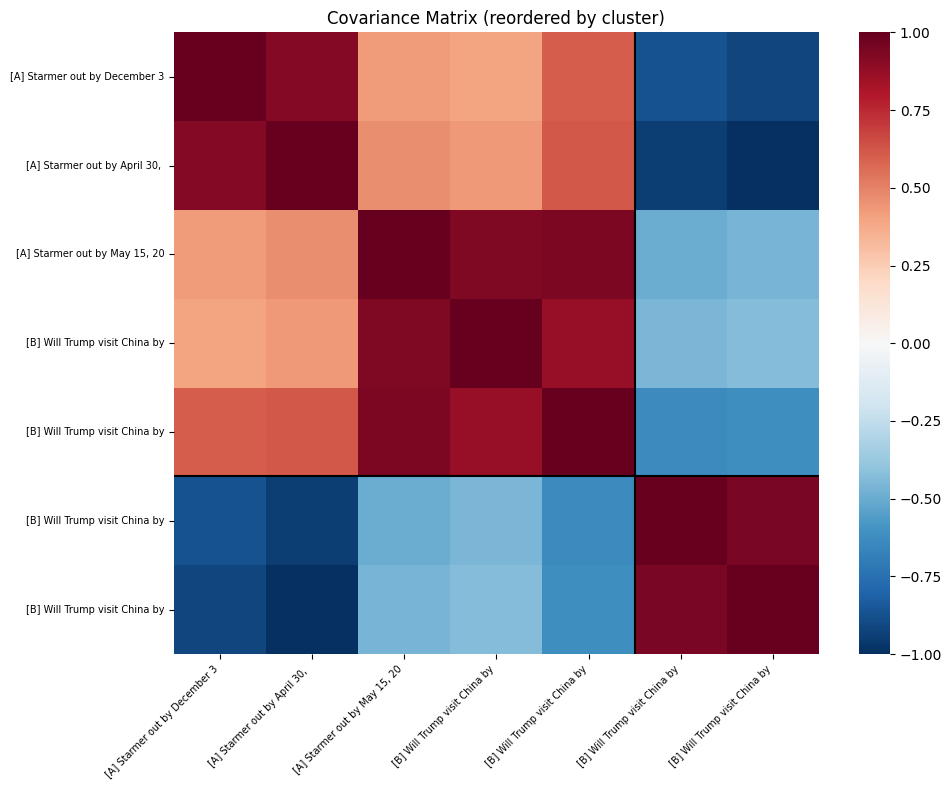

In [10]:
# Covariance heatmap (reordered by cluster)
plot_covariance_heatmap(result["cov_matrix"], market_labels, result["labels"]);

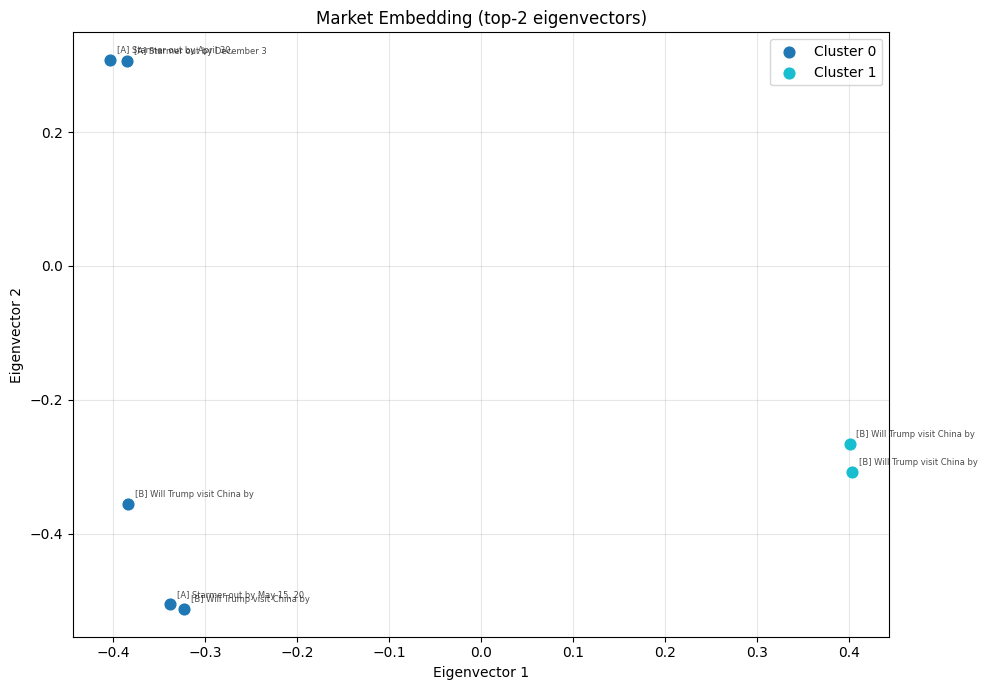

In [11]:
# Embedding scatter — color by PREDICTED cluster, label includes ground truth [A]/[B]
plot_embedding(result["embedding"], market_labels, result["labels"]);

## 7. Assessment

### Signal choice: price levels vs. returns
Polymarket sub-markets trade sparsely — most have only a handful of price changes per day.
Forward-filling to an hourly grid makes log-odds returns 95%+ zeros, producing noisy
covariance matrices. Using **centered price levels** avoids this: the covariance captures
how price trajectories co-move over the full window, not just at the sparse instants of trading.

### Did BlindCD recover the two-event structure?
- **Accuracy:** *(see output above)*
- 100% means BlindCD perfectly separated two unrelated events from co-movement alone.
- Even modest accuracy (>70%) confirms the pipeline works — the signal is real.

### What's next?
- If accuracy is high: try harder cases (events from the same domain, e.g. two different sports)
- Phase 1: scale to more events, larger K, and evaluate robustness